# Part 2: Tool Calling & Reasoning Integration (40%)

> Objective: Extend your Part 1 solution by integrating external tools and LLM reasoning. This 
task evaluates your ability to combine structured data extraction with intelligent decision-making using prompt engineering and function calling.

## Step 1: Set up the MCP server

The MCP server is set up in `extractor_server.py`


## Step 2: Bind tools to our LLM model

The local MCP server exposes two tools:
- `extract_data`: Used to extract information from a document.
- `parse_date`: Normalizes dates into ISO format (YYYY-MM-DD). To trigger this tool, the system prompt instructs the LLM to always call it whenever any form of date is extracted.


In [4]:
from ai_engineering_assignment.settings import MainConfig
from ai_engineering_assignment.part2.model import mcp_client, model

configs = MainConfig()

In [5]:
tools = await mcp_client.get_tools()

In [6]:
tools

[StructuredTool(name='extract_data', description="\nExtract a piece of information from a document that has already been converted to Docling's JSON format.\nUse this tool when the user asks a question about the content of a specific document.\n\nArgs:\n    user_query (str): A natural-language question describing what to extract from the document\n    doc_json_path (str): Absolute file path to the Docling JSON export of the document to search\n", args_schema={'properties': {'user_query': {'title': 'User Query', 'type': 'string'}, 'doc_json_path': {'title': 'Doc Json Path', 'type': 'string'}}, 'required': ['user_query', 'doc_json_path'], 'title': 'extract_dataArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x73f9efb89580>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x73f9ef68b100>),
 StructuredTool(name='parse_date', description='\nConvert a date string in any common human-read

In [7]:
model_with_tools = model.bind_tools(tools)

## Step 3: Query the LLM

To get back the structured dictionary required, I used structured output, with the schema defined in `src/ai_engineering_assignment/part2/schema/query.py`.

For the `status` field, instead of relying on the LLM, I realized that since the logic is rule-based, it could be computed directly via Pydantic's `model_validator`. This saves on token cost and avoids any incorrect classification by the LLM.

In [8]:
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display
from loguru import logger

from ai_engineering_assignment.part2.schema.query import DateResult
from ai_engineering_assignment.part2.model import model
from ai_engineering_assignment.part2.utils import collect_images
from langchain.agents.factory import create_agent
from ai_engineering_assignment.part2.prompts import SYSTEM_PROMPT_TEMPLATE

In [9]:
# Set up the agent with the tools
agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=SYSTEM_PROMPT_TEMPLATE.format(
        doc_json_path=str(configs.ROOT / "data" / configs.app.data.processed)
    ),
    response_format=DateResult,
)

When a query comes in, the LLM decides whether any tools are required to answer it. If so, the relevant tool is triggered and the result is parsed back into the LLM. If no further tools are required, the loop ends and the final answer is returned to the user.


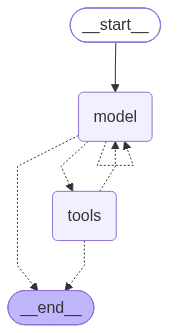

In [10]:
display(IPImage(agent.get_graph().draw_mermaid_png()))

In [11]:
# The two input queries that we are testing
queries = ["The document's distribution date.", "The date relating to estate duty."]

2026-07-25 12:02:45.085 | INFO     | __main__:<module>:4 - QUERY: The document's distribution date.


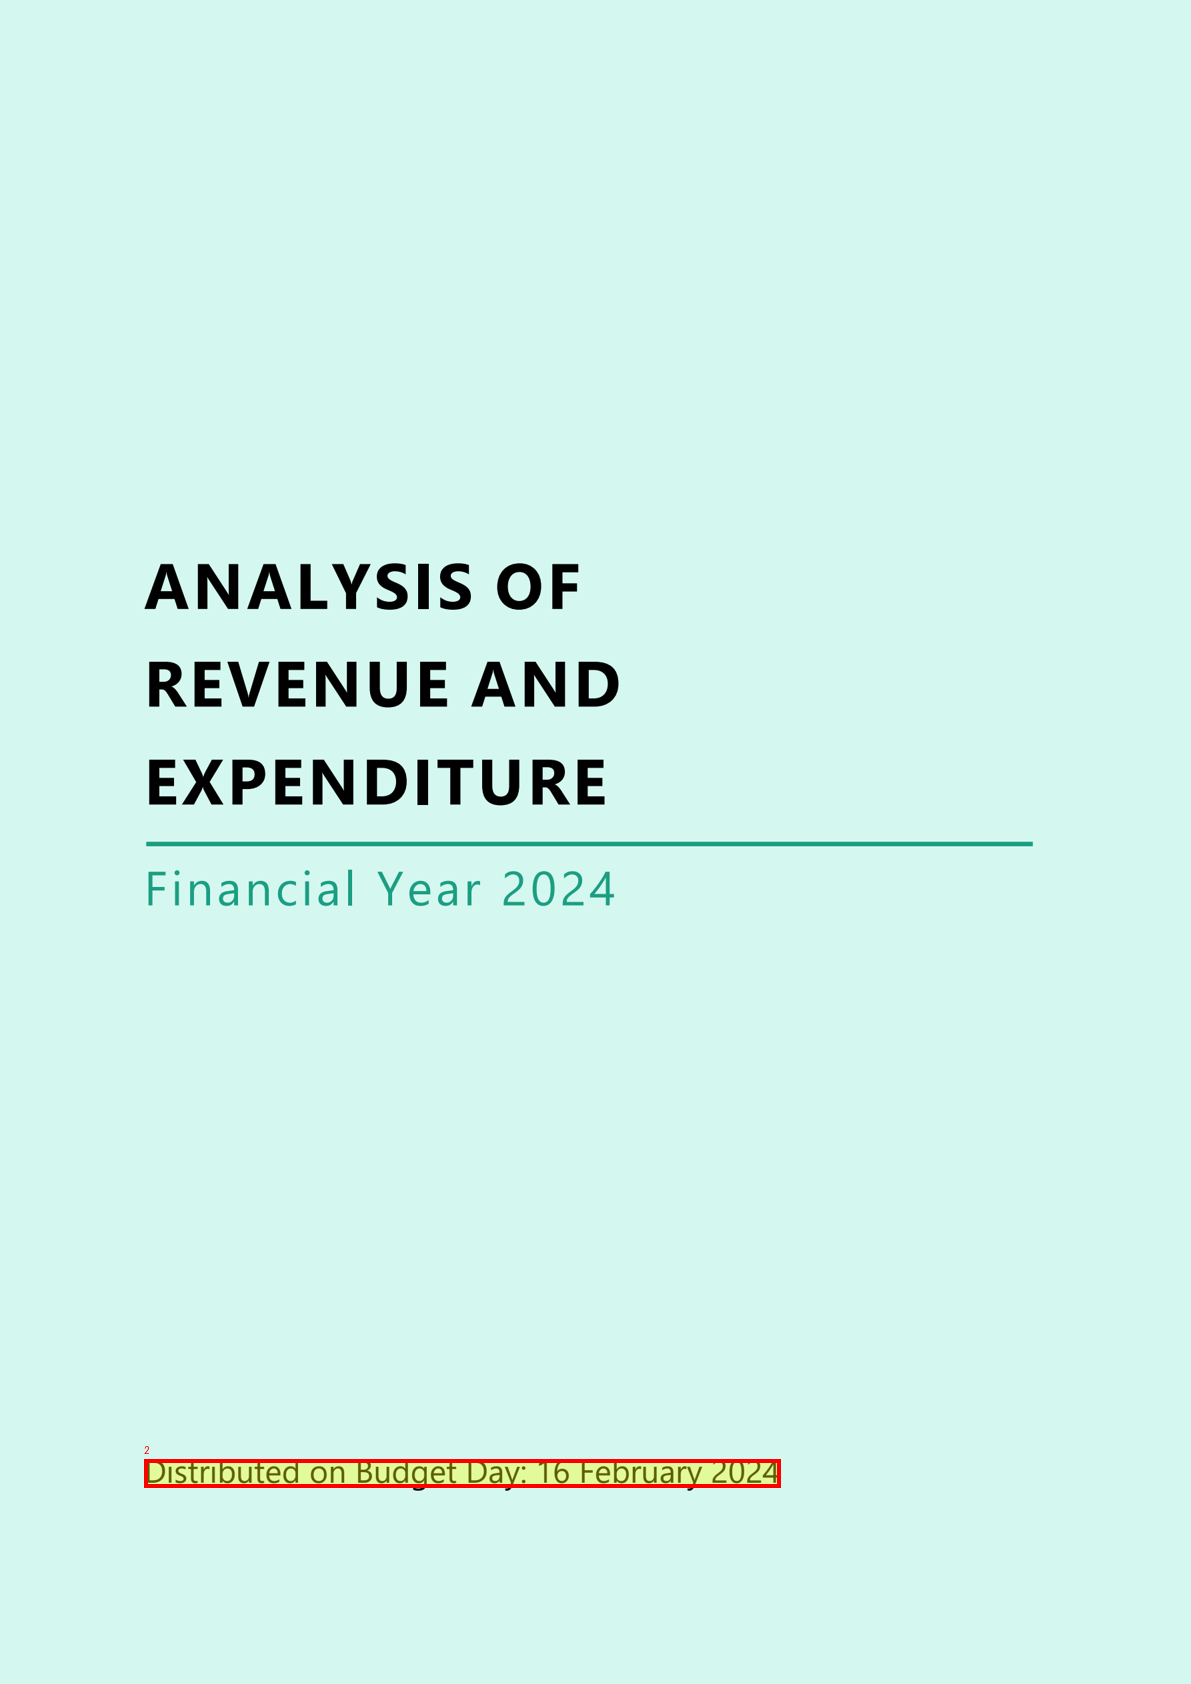

2026-07-25 12:03:03.219 | INFO     | __main__:<module>:17 - ANSWER: {'original_text': '16 February 2024', 'normalized_date': '2024-02-16', 'status': 'Upcoming', 'self_refs': ['#/texts/2']}
2026-07-25 12:03:03.221 | INFO     | __main__:<module>:4 - QUERY: The date relating to estate duty.


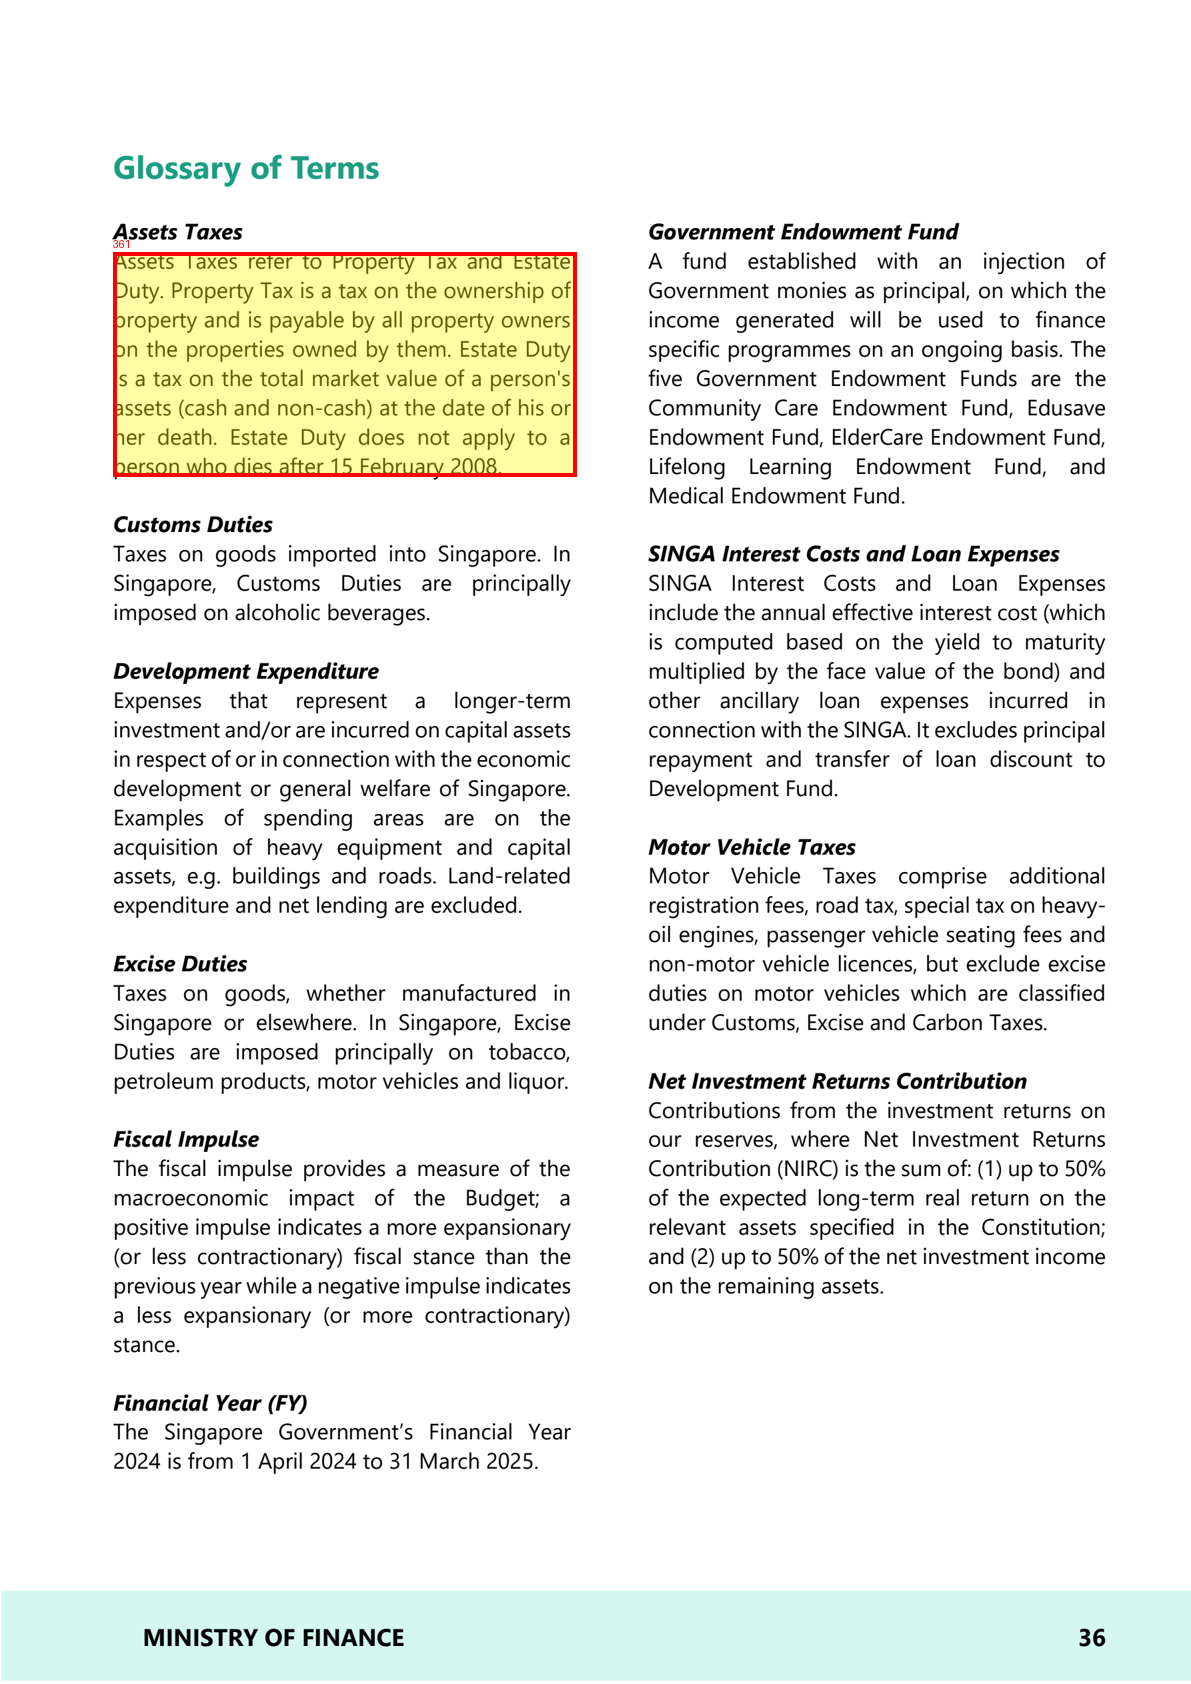

2026-07-25 12:03:19.348 | INFO     | __main__:<module>:17 - ANSWER: {'original_text': '15 February 2008', 'normalized_date': '2008-02-15', 'status': 'Expired', 'self_refs': ['#/texts/361']}


In [12]:
# Loop through each of the query and save the final output
final_output = []
for query in queries:
    logger.info(f"QUERY: {query}")

    result = await agent.ainvoke({"messages": [{"role": "user", "content": query}]})

    # Return the image
    image_paths = collect_images(result)

    if image_paths:
        for path in image_paths:
            image = PILImage.open(path)
            display(image)

    dict_output = result["structured_response"].model_dump()
    logger.info(f"ANSWER: {dict_output}")

    final_output.append(dict_output)

In [13]:
final_output

[{'original_text': '16 February 2024',
  'normalized_date': '2024-02-16',
  'status': 'Upcoming',
  'self_refs': ['#/texts/2']},
 {'original_text': '15 February 2008',
  'normalized_date': '2008-02-15',
  'status': 'Expired',
  'self_refs': ['#/texts/361']}]